In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Usando dispositivo: cuda
Episodio 0	Score Promedio: 24.00
Episodio 50	Score Promedio: 15.80
Episodio 100	Score Promedio: 38.60
Episodio 150	Score Promedio: 94.12
¡Resuelto en el episodio 191!


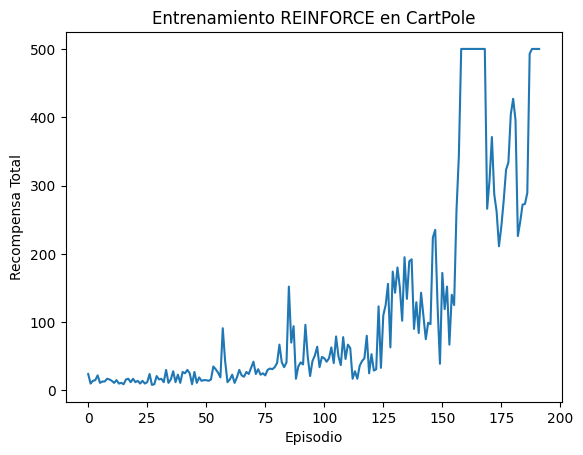

In [2]:
# 1. Configuración del Entorno e Importaciones
import gymnasium as gym  # O 'import gym' dependiendo de tu versión en Kaggle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque

# Configurar dispositivo (GPU/TPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 2. Hiperparámetros
LEARNING_RATE = 1e-2  # Tasa de aprendizaje
GAMMA = 0.99          # Factor de descuento (cuánto importan las recompensas futuras)
EPISODES = 1000       # Cantidad de episodios a entrenar
HIDDEN_SIZE = 128     # Neuronas en la capa oculta

# 3. Entorno de RL
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# 4. Agente (Sustituye al DQN por una Policy Network)
# En REINFORCE, la red no estima el valor (Q), sino la probabilidad de la acción.
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1) # Importante para obtener probabilidades

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x

policy = PolicyNetwork(state_size, action_size, HIDDEN_SIZE).to(device)
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)

# 5. Políticas (Selección de Acción)
# REINFORCE es estocástico: elige acciones basadas en probabilidades, no siempre la "mejor" (greedy).
def select_action(state):
    state = torch.from_numpy(state).float().unsqueeze(0).to(device)
    probs = policy(state)
    
    # Crea una distribución categórica (como lanzar una moneda cargada)
    m = Categorical(probs)
    action = m.sample()
    
    # Guardamos el logaritmo de la probabilidad para el entrenamiento (Paso 8/9)
    return action.item(), m.log_prob(action)

# 7. "Búfer" (Adaptado para REINFORCE)
# A diferencia de DQN, REINFORCE no guarda historia antigua. 
# Solo guarda lo que pasó en EL episodio actual.
class EpisodeMemory:
    def __init__(self):
        self.log_probs = []
        self.rewards = []
    
    def clear(self):
        self.log_probs = []
        self.rewards = []
        
    def add(self, log_prob, reward):
        self.log_probs.append(log_prob)
        self.rewards.append(reward)

# 9. Entrenamiento del Agente (Función de actualización)
def update_policy(memory):
    returns = []
    R = 0
    
    # Calculamos el retorno descontado (Discounted Return) desde el final hacia atrás
    for r in memory.rewards[::-1]:
        R = r + GAMMA * R
        returns.insert(0, R)
        
    returns = torch.tensor(returns).to(device)
    
    # Normalización (opcional pero recomendada para estabilidad en GPU)
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)
    
    policy_loss = []
    for log_prob, R in zip(memory.log_probs, returns):
        # La fórmula mágica de REINFORCE: -log(prob) * Retorno
        policy_loss.append(-log_prob * R)
        
    optimizer.zero_grad()
    policy_loss = torch.stack(policy_loss).sum()
    policy_loss.backward()
    optimizer.step()

# ==========================================
# Bucle Principal (Combina Pasos 6, 8 y 9)
# ==========================================

scores = []
memory = EpisodeMemory()

for i_episode in range(EPISODES):
    state, _ = env.reset()
    ep_reward = 0
    
    # 8. Recopilación de Datos (Interacción)
    while True:
        action, log_prob = select_action(state)
        next_state, reward, done, truncated, _ = env.step(action)
        
        memory.add(log_prob, reward)
        ep_reward += reward
        state = next_state
        
        if done or truncated:
            break
            
    # Paso 9: Entrenar al final del episodio
    update_policy(memory)
    memory.clear()
    
    # 6. Métricas
    scores.append(ep_reward)
    
    if i_episode % 50 == 0:
        print(f"Episodio {i_episode}\tScore Promedio: {np.mean(scores[-50:]):.2f}")
        
    # Condición de parada si el agente ya aprendió
    if np.mean(scores[-100:]) >= 195.0:
        print(f"¡Resuelto en el episodio {i_episode}!")
        break

# 10. Visualización
plt.plot(scores)
plt.ylabel('Recompensa Total')
plt.xlabel('Episodio')
plt.title('Entrenamiento REINFORCE en CartPole')
plt.show()

In [3]:
# Instalación de dependencias del sistema (Linux)
!apt-get update > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay > /dev/null 2>&1

In [4]:
from pyvirtualdisplay import Display
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML

# 1. Iniciar pantalla virtual
virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

# 2. Configurar entorno para grabación
# Importante: render_mode='rgb_array' es necesario para que la cámara "vea"
env_video = gym.make('CartPole-v1', render_mode='rgb_array')

# Usamos el Wrapper RecordVideo
# video_folder: dónde se guardará
# episode_trigger: lambda x: True graba todos los episodios que ejecutemos aquí
env_video = RecordVideo(env_video, video_folder="./video_result", episode_trigger=lambda x: True)

# 3. Correr un episodio con el agente entrenado
state, _ = env_video.reset()
done = False
truncated = False
total_reward = 0

while not done and not truncated:
    # Usamos tu función select_action existente
    # Nota: select_action devuelve (action, log_prob), solo necesitamos la action
    action, _ = select_action(state)
    
    state, reward, done, truncated, _ = env_video.step(action)
    total_reward += reward

env_video.close()
print(f"Juego grabado. Recompensa total: {total_reward}")

/usr/local/lib/python3.11/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.is_vector_env to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.is_vector_env` for environment variables or `env.get_attr('is_vector_env')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/lo

Moviepy - Building video /kaggle/working/video_result/rl-video-episode-0.mp4.
Moviepy - Writing video /kaggle/working/video_result/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/video_result/rl-video-episode-0.mp4
Juego grabado. Recompensa total: 500.0


In [5]:
def show_video():
    mp4list = glob.glob('video_result/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        return HTML(data='''<video alt="test" autoplay 
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii')))
    else:
        print("No se encontró el video")

show_video()